## ML MODEL SUMMARIZER - DECISION TREE WITH CLAUDE API INTEGRATION

### 01: Data Exploration Workbook

==================================================================
#### SECTION 1: IMPORT PACKAGES, DATA LOADING, INITIAL EXPLORATION
==================================================================

In [89]:
import pandas as pd
import numpy as np
import random

In [90]:
# Set the display format for all floats in the DataFrame
pd.options.display.float_format = '{:.4f}'.format


In [91]:
df = pd.read_csv("../data/accepted_2007_to_2018Q4.csv.gz", compression="gzip", low_memory=False)

In [92]:
print(f"Dataset shape: {df.shape}")
print(f"\nAll columns ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

Dataset shape: (2260701, 151)

All columns (151 total):
  1. id
  2. member_id
  3. loan_amnt
  4. funded_amnt
  5. funded_amnt_inv
  6. term
  7. int_rate
  8. installment
  9. grade
 10. sub_grade
 11. emp_title
 12. emp_length
 13. home_ownership
 14. annual_inc
 15. verification_status
 16. issue_d
 17. loan_status
 18. pymnt_plan
 19. url
 20. desc
 21. purpose
 22. title
 23. zip_code
 24. addr_state
 25. dti
 26. delinq_2yrs
 27. earliest_cr_line
 28. fico_range_low
 29. fico_range_high
 30. inq_last_6mths
 31. mths_since_last_delinq
 32. mths_since_last_record
 33. open_acc
 34. pub_rec
 35. revol_bal
 36. revol_util
 37. total_acc
 38. initial_list_status
 39. out_prncp
 40. out_prncp_inv
 41. total_pymnt
 42. total_pymnt_inv
 43. total_rec_prncp
 44. total_rec_int
 45. total_rec_late_fee
 46. recoveries
 47. collection_recovery_fee
 48. last_pymnt_d
 49. last_pymnt_amnt
 50. next_pymnt_d
 51. last_credit_pull_d
 52. last_fico_range_high
 53. last_fico_range_low
 54. collectio

In [93]:
#create a copy of the dataframe for exploration and modeling
df_model = df.copy()

=================================================================
#### SECTION 2: TARGET VARIABLE ENGINEERING
=================================================================

In [94]:
# Check the target variable
print("\n" + "="*50)
print("Loan Status Distribution:")
print(df_model['loan_status'].value_counts())


Loan Status Distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [95]:
# convert "Does not meet the credit policy. Status:Fully Paid" to "Fully Paid" and similar for "Charged Off"
df_model['loan_status'] = df_model['loan_status'].replace({'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
                                         'Does not meet the credit policy. Status:Charged Off': 'Charged Off'})

In [96]:
#convert Default to Charged Off
df_model['loan_status'] = df_model['loan_status'].replace({'Default': 'Charged Off'})

In [97]:
# check unique values again
df_model['loan_status'].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', nan], dtype=object)

In [98]:
#check null or NaN values in target variable
df_model[df_model['loan_status'].isna()].shape

(33, 151)

In [99]:
#drop rows with null target variable
df_model = df_model.dropna(subset=['loan_status'])

In [100]:
# Create binary default target
def create_default_flag(status):
    if 'Fully Paid' in status:
        return 0  # Good loan
    elif 'Charged Off' in status:
        return 1  # Bad loan
    else:
        return None  # Can't determine yet (Current, Late, etc.)

In [101]:
default_flag = []

for i in df_model['loan_status']:
    default_flag.append(create_default_flag(i))

In [102]:
df_model['default_flag'] = default_flag

# Drop loans where outcome is unknown
df_model = df_model[df_model['default_flag'].notna()].copy()

=================================================================
#### SECTION 3: FEATURE SELECTION
=================================================================

In [103]:
print(f"We currently have {len(df_model.columns)} columns.") 

We currently have 152 columns.


In [104]:
#intuitive drop list based on domain knowledge and relevance to the target variable
all_features = [
    # Loan details
     'funded_amnt', 'loan_amnt', 'term', 'int_rate', 'installment', 
    
    # Borrower profile
    'annual_inc', 'emp_length', 'home_ownership', 
    
    # Credit metrics
    'dti',  'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'pub_rec_bankruptcies', 'tot_cur_bal', 'total_rev_hi_lim', 

    #credit numerical features
    'num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op','mo_sin_old_rev_tl_op',
    'bc_util','bc_open_to_buy','avg_cur_bal','acc_open_past_24mths', 

    #Will be deleted after feature engineering
    'grade', 'sub_grade', 'purpose', 'verification_status',
    'issue_d', 'addr_state', 'earliest_cr_line', 'zip_code','last_pymnt_amnt',
    'title', 'application_type', 'emp_title', 'mort_acc', 'fico_range_low', 'fico_range_high',
    
    #targets
   'default_flag'


]

In [105]:

# combining features to filter the entire dataframe to only include the selected features
df_model = df_model[all_features].copy()

In [106]:
print(f"We now have {len(df_model.columns)} columns.")

We now have 42 columns.


In [107]:
#based on signficant missing values and relevance to the target, we will drop the following columns:
missing_fractions = df_model.isnull().mean().sort_values(ascending=False)

#lets drop the columns with more than 50% missing values
cols_to_drop = missing_fractions[missing_fractions > 0.3].index.tolist()
print(f"\nDropping {len(cols_to_drop)} columns with >30% missing values:")
for col in cols_to_drop:
    print(f"- {col} ({missing_fractions[col]:.2%} missing)")
df_model = df_model.drop(columns=cols_to_drop)


Dropping 0 columns with >30% missing values:


In [108]:
print(f"We now have {len(df_model.columns)} columns.")

We now have 42 columns.


=================================================================
#### SECTION 4: FEATURE CLEANING AND ENCODING
=================================================================

In [109]:
#Convert term to integer after nan removal
df_model['term'] = df_model['term'].replace(" ", "").str[:3].astype(int)

In [110]:
df_model['emp_length'] = df_model['emp_length'].replace({"10+ years": 10, "9 years": 9, "8 years": 8, "7 years": 7, "6 years": 6, "5 years": 5, "4 years": 4, "3 years": 3, "2 years": 2, "1 year": 1, "< 1 year": 0})

/var/folders/b6/z2j2f1js49s1rw1gfk04vyp40000gn/T/ipykernel_14491/395925736.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model['emp_length'] = df_model['emp_length'].replace({"10+ years": 10, "9 years": 9, "8 years": 8, "7 years": 7, "6 years": 6, "5 years": 5, "4 years": 4, "3 years": 3, "2 years": 2, "1 year": 1, "< 1 year": 0})


In [111]:
# Fix grade encoding BEFORE train/test split
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
sub_grade_map = {
    'A1':1,'A2':2,'A3':3,'A4':4,'A5':5,
    'B1':6,'B2':7,'B3':8,'B4':9,'B5':10,
    'C1':11,'C2':12,'C3':13,'C4':14,'C5':15,
    'D1':16,'D2':17,'D3':18,'D4':19,'D5':20,
    'E1':21,'E2':22,'E3':23,'E4':24,'E5':25,
    'F1':26,'F2':27,'F3':28,'F4':29,'F5':30,
    'G1':31,'G2':32,'G3':33,'G4':34,'G5':35
}

df_model['grade_encoded'] = df_model['grade'].map(grade_map)
df_model['sub_grade_encoded'] = df_model['sub_grade'].map(sub_grade_map)

df_model['purpose_encoded'] = df_model['purpose'].astype('category').cat.codes
df_model['home_ownership_encoded'] = df_model['home_ownership'].astype('category').cat.codes
df_model['verification_status_encoded'] = df_model['verification_status'].astype('category').cat.codes

In [112]:
numeric_cols = df_model.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print(f"Remaining NaNs: {df_model.isnull().sum().sum()}")

Remaining NaNs: 102642


In [113]:
excess_null_cols = df_model.isnull().sum().index[df_model.isnull().sum() > 100].to_list()

In [114]:
df_model.drop(columns=excess_null_cols, inplace=True)

In [115]:
numeric_cols = df_model.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print(f"Remaining NaNs: {df_model.isnull().sum().sum()}")

Remaining NaNs: 30


In [116]:
df_model.dropna(inplace=True) #drop remaining nulls just to be safe, but we should have very few if any left at this point

In [117]:
# Group into regions
region_map = {
    'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
    'Midwest': ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'],
    'South': ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX'],
    'West': ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']
}

def get_region(state):
    for region, states in region_map.items():
        if state in states:
            return region
    return 'Unknown'

df_model['region_encoded'] = df_model['addr_state'].map(lambda x: get_region(x))
df_model['region_encoded'] = df_model['region_encoded'].astype('category').cat.codes

In [118]:
def application_type_to_code(app_type):
    if app_type == 'Individual':
        return 0
    elif app_type == 'Joint App':
        return 1
    else:
        return 2  # For any other types, if they exist

In [119]:
application_type = []
for i in df_model['application_type']:
    application_type.append(application_type_to_code(i))

df_model['application_type_encoded'] = application_type

In [120]:
# Convert to datetime
df_model['earliest_cr_line'] = pd.to_datetime(df_model['earliest_cr_line'], format='%b-%Y', errors='coerce')
df_model['issue_d'] = pd.to_datetime(df_model['issue_d'], format='%b-%Y', errors='coerce')

# Calculate years of credit history at loan origination
df_model['credit_age_years'] = (df_model['issue_d'] - df_model['earliest_cr_line']).dt.days / 365.25

# Handle negatives/NaNs
df_model['credit_age_years_encoded'] = df_model['credit_age_years'].clip(lower=0)
df_model['credit_age_years_encoded'] = df_model['credit_age_years_encoded'].fillna(df_model['credit_age_years_encoded'].median())

In [121]:
df_model['mort_acc'] = df_model['mort_acc'].fillna(0)
df_model['mort_acc'] = df_model['mort_acc'].clip(upper=10) # Cap at 10 to reduce skew and outliers; extreme values are unrealistic and likely data errors, and capping helps prevent them from dominating the model training.

In [122]:
# Remove zip_code - over 945 unique values and the last two are masked. 
# It is unlikely that zip code will provide significant predictive power, 
# and it could lead to overfitting, so we will drop it.
df_model = df_model.drop('zip_code', axis=1, errors='ignore')

In [123]:
#log transform last payment amount to reduce skew
df_model['last_pymnt_amnt_log_encoded'] = df_model['last_pymnt_amnt'].apply(lambda x: np.log10(x+1))

In [124]:
df_model['funded_amnt_log_encoded'] = df_model['funded_amnt'].apply(lambda x: np.log10(x+1))

In [125]:
df_model['fico_avg_encoded'] = (df_model['fico_range_low'] + df_model['fico_range_high']) / 2

In [126]:
df_model['payment_to_income_encoded'] = round(df_model['installment'] / (df_model['annual_inc'] / 12), 2)
df_model['payment_to_income_encoded'] = df_model['payment_to_income_encoded'].replace([np.inf, -np.inf], np.nan).fillna(0)

In [127]:
# Remove the following columns after encoding and feature engineering:
# 'grade', 'sub_grade', 'purpose', 'home_ownership', 'verification_status', 'addr_state'
# Now drop addr_state
drop_list = ['grade', 'sub_grade', 'purpose', 'home_ownership',
             'verification_status',
             'loan_status', 'fico_range_low', 'fico_range_high',
             
             'issue_d', 'addr_state', 'earliest_cr_line', 'zip_code','last_pymnt_amnt',
             'title', 'application_type', 'emp_title', 'mort_acc'  ]
#### df_model.drop('addr_state', axis=1, inplace=True)
#### check_list.remove('addr_state', 'grade', 'sub_grade')

In [128]:
df_model.drop(columns=drop_list, inplace=True, errors='ignore')

=================================================================
#### SECTION 6: TARGET VARIABLE DISTRIBUTION TESTING AND REBALANCING
=================================================================


Target distribution:
default_flag
0.0000    1078712
1.0000     269357
Name: count, dtype: int64

Default rate: 19.98%


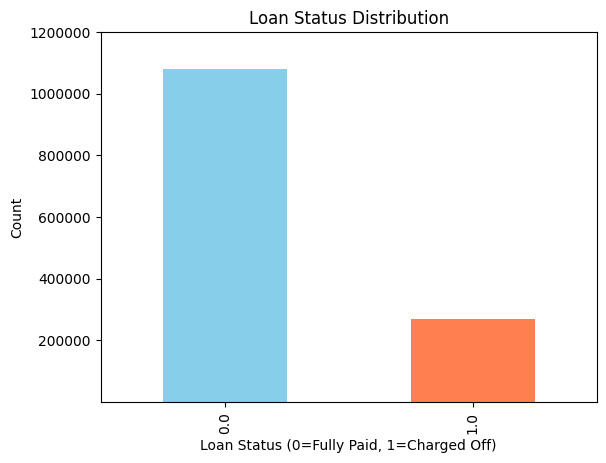

In [129]:
#Visualize target distribution
print("\nTarget distribution:")
print(df_model['default_flag'].value_counts())
print(f"\nDefault rate: {df_model['default_flag'].mean():.2%}")

df_model['default_flag'].value_counts().plot(kind='bar', color = ['skyblue', 'coral'],
                                             title='Loan Status Distribution')
plt.xlabel('Loan Status (0=Fully Paid, 1=Charged Off)')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='y')
new_tick_positions = [200000, 400000, 600000, 800000, 1000000, 1200000]
plt.yticks(new_tick_positions)
plt.show()

Data is signficantly imbalanced. We can leverage resamplng to balance the data set.

In [130]:
#set the seed for reproducibility across all random operations
seed = 42
np.random.seed(seed)
random.seed(42)

In [131]:
loanstatus_0 = df_model[df_model["default_flag"]==0]
loanstatus_1 = df_model[df_model["default_flag"]==1]
subset_of_loanstatus_0 = loanstatus_0.sample(n=20000)
subset_of_loanstatus_1 = loanstatus_1.sample(n=20000)
dataset = pd.concat([subset_of_loanstatus_1, subset_of_loanstatus_0])
dataset = dataset.sample(frac=1).reset_index(drop=True)
print("Current shape of dataset :",dataset.shape)
dataset.head()

Current shape of dataset : (40000, 39)


,funded_amnt,loan_amnt,term,int_rate,installment,annual_inc,emp_length,dti,delinq_2yrs,inq_last_6mths,...,home_ownership_encoded,verification_status_encoded,region_encoded,application_type_encoded,credit_age_years,credit_age_years_encoded,last_pymnt_amnt_log_encoded,funded_amnt_log_encoded,fico_avg_encoded,payment_to_income_encoded
0,10525.0000,10525.0000,36,16.2900,371.5400,50000.0000,5.0000,27.2900,0.0000,0.0000,...,1,1,2,0,9.4182,9.4182,2.5712,4.0223,687.0000,0.0900
1,6250.0000,6250.0000,36,15.8000,219.1200,21000.0000,5.0000,24.8000,0.0000,0.0000,...,4,0,2,0,12.6626,12.6626,2.3422,3.7959,662.0000,0.1300
2,20000.0000,20000.0000,36,10.9100,653.9300,180000.0000,10.0000,4.7400,0.0000,0.0000,...,1,1,0,0,31.7536,31.7536,2.1761,4.3011,672.0000,0.0400
3,8000.0000,8000.0000,36,16.0200,281.3400,48000.0000,5.0000,0.6300,2.0000,0.0000,...,4,2,4,0,21.7495,21.7495,2.4508,3.9031,662.0000,0.0700
4,3200.0000,3200.0000,36,13.1100,107.9900,25000.0000,6.0000,17.8600,0.0000,0.0000,...,5,0,0,0,8.1697,8.1697,2.0374,3.5053,692.0000,0.0500


In [132]:
# Need to output the final dataframe for use in the next notebook
df_model.to_csv("../data/processed_loan_data.csv", index=False)